## **Actor-Critic Based Sepsis Treatment Optimization**

### Group ID:
### Group Members Name with Student ID:
| Name | BITS ID|
|------| -------|
|SUKAMATI NAVEEN KUMAR | 2024AA05078 |
|MANISH GARG | 2024AA05118
|GAURAV DHAMI | 2024AA05077
| HARSHIT KUMAR HALWAN | 2024AA059281 |



# 1. **Environment Modeling**
Each ICU stay is treated as a single RL episode. The environment is built to simulate the clinical decision-making process:

**State Representation:** A vector of patient vitals and demographics:

* Mean Blood Pressure (mean_bp)

* Oxygen Saturation (spo2)

* Respiratory Rate (resp_rate)

* Age

* Gender (encoded)

* **Action Space:** 99 discrete treatment actions, including a NO_ACTION option, representing various medical interventions.

* **Episode Structure:** One ICU stay = One episode. The agent interacts with the environment step-by-step, receiving observations and rewards.

# 2. **Reward Function Design**
The reward function is crafted to reflect clinical goals:

* **Positive Rewards:** For stabilizing vitals (e.g., improving spo2, maintaining mean_bp)

* **Negative Rewards:** For deteriorating vitals or unnecessary interventions

* **Penalties:** For choosing NO_ACTION when intervention is needed

This function guides the agent toward clinically meaningful behavior.

# New Section
3. **Actor-Critic Agent Training**
The agent consists of two neural networks:

* **Actor:** Learns the policy by outputting probabilities over actions given a state.

* **Critic:** Estimates the value of a state to guide the actor’s learning.

Training involves:

* Sampling actions from the actor

* Receiving rewards and next states from the environment

* Updating the critic using Temporal Difference (TD) error

* Updating the actor using policy gradients weighted by advantage estimates

* The agent is trained over multiple episodes, gradually improving its policy.

# 4. **Evaluation Metrics**
Two key metrics are tracked during training:

* **Average Episode Reward:** Measures how well the agent is performing over time.

* **Episode Lengths:** Indicates how long the agent keeps patients stable before termination.

These metrics are visualized using line plots to assess learning progress and stability.

# 5.**Insights & Behavior**
* The agent initially performs poorly, often choosing suboptimal actions.

* Over time, it learns to stabilize vitals more effectively, increasing both rewards and episode lengths.

* The model demonstrates the ability to learn patient-specific treatment strategies.

* Stability improves with training, and the agent avoids unnecessary interventions.

# **Future Directions**
* Incorporate more features (e.g., lab results, comorbidities)

* Use attention mechanisms for temporal dependencies

* Validate on real-world ICU datasets

* Collaborate with clinicians for interpretability and safety

## **Objective**:
The goal of this assignment is to model the ICU treatment process using Reinforcement Learning, specifically the Actor-Critic method. The agent should learn an optimal intervention policy from historical ICU data. Each patient's ICU stay is treated as an episode consisting of time-stamped clinical observations and treatments.

**Team tasks:**
1.	Model the ICU treatment process as a Reinforcement Learning (RL) environment.
2.	Train an Actor-Critic agent to suggest medical interventions based on the patient’s current state (vitals and demographics).





## Dataset:

We have dataset provided in the following link:

https://drive.google.com/file/d/1Nf2tPLTKZ8ucsbhgGmmQzD4RWAUgWBpT/view?usp=sharing

**Features:**

•	*Vitals*: mean_bp, spo2, resp_rate

•	*Demographics*: age, gender

•	*Action*: Medical intervention (e.g., "Vancomycin", "NaCl 0.9%", or NO_ACTION)

•	*Identifiers*: timestamp, subject_id, hadm_id, icustay_id


## State Space :

Each state vector consists of: mean_bp (Mean Blood Pressure) , spo2 (Oxygen Saturation), resp_rate (Respiratory Rate), age, One-hot encoded gender


## Action Space :

•	The agent selects one discrete action from 99 possible medical interventions (e.g., Vancomycin, Fentanyl, PO Intake, etc.

•	You should integer encode or one-hot encode these interventions.



## Reward Function:

At each time step, the agent receives a reward based on how close the patient's vitals are to clinically normal ranges. The reward encourages the agent to take actions that stabilize the patient's vital signs:

$$
\text{Reward}_t = - \left( (MBP_t - 90)^2 + (SpO2_t - 98)^2 + (RR_t - 16)^2 \right)
$$


**Explanation:**

•	MBP (mean_bp): Target = 90 mmHg

•	SpO₂ (spo2): Target = 98%

•	RR (resp_rate): Target = 16 breaths/min

Each term penalizes the squared deviation from the healthy target. The smaller the difference, the higher (less negative) the reward.

**Example:**

Suppose at time t, the vitals are:

•	MBP = 88

•	SpO₂ = 97

•	RR = 20

Then the reward is:

$$
\text{Reward}_t = - \left[ (88 - 90)^2 + (97 - 98)^2 + (20 - 16)^2 \right] = - (4 + 1 + 16) = -21
$$


*A lower (more negative) reward indicates worse vitals, guiding the agent to learn actions that minimize this penalty.*





### Episode Termination

An episode ends when the ICU stay ends. To define this:

1. **Group the data** by `subject_id`, `hadm_id`, and `icustay_id`  
   → Each group represents one ICU stay = one episode.

2. **Sort each group** by `timestamp`  
   → Ensures the time progression is correct.

3. **For each time step** in a group (i.e., each row):  
   → Check if it is the **last row** in that group.  
   &nbsp;&nbsp;&nbsp;&nbsp;• If **yes**, then mark `done = True` (end of episode)  
   &nbsp;&nbsp;&nbsp;&nbsp;• If **no**, then mark `done = False` (continue episode)


## Requirements and Deliverables:

Implement the Sepsis
Treatment Optimization Problem for the given above scenario for the below mentioned RL method.

### Initialize constants and import libraries

In [5]:
# Libraries
import pandas as pd
from google.colab import drive
import gym
from gym import spaces
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Initialize Constants
# ===============================

# --- Paths ---
DRIVE_MOUNT_PATH = "/content/drive"  # Google Drive mount location
DATASET_FILE_PATH = "/content/drive/MyDrive/Colab_Notebooks/Sepsis_datset.csv"  # ICU dataset CSV path

# --- Environment ---
NUM_ACTIONS = 99                  # Total available treatment actions
OBSERVATION_DIM = 5               # State vector length (mean_bp, spo2, resp_rate, age, gender)

# --- Reward Targets ---
TARGET_MEAN_BP = 90                # mmHg target for mean blood pressure
TARGET_SPO2 = 98                   # % target for oxygen saturation
TARGET_RESP_RATE = 16              # breaths per minute target for respiratory rate

# --- Training Hyperparameters ---
NUM_EPISODES = 1000                # Number of training episodes
ACTOR_LR = 1e-4                     # Learning rate for Actor network
CRITIC_LR = 1e-3                     # Learning rate for Critic network
GAMMA = 0.99                         # Discount factor for future rewards
ROLLING_AVG_WINDOW = 50              # Window size for rolling average in reward plot

# --- Other Settings ---
FORCE_REMOUNT_DRIVE = True          # Force Google Drive remount


### Load Dataset    (0.5 Mark)

In [7]:
# --- Mount Google Drive ---
drive.mount(DRIVE_MOUNT_PATH, force_remount=FORCE_REMOUNT_DRIVE)  # Mount cloud storage

# --- Load dataset ---
df = pd.read_csv(DATASET_FILE_PATH)  # Read CSV dataset
df['timestamp'] = pd.to_datetime(df['timestamp'])  # Convert timestamp to datetime
df.sort_values(by=['subject_id', 'hadm_id', 'icustay_id', 'timestamp'], inplace=True)  # Sort per patient episode
df['gender'] = df['gender'].map({'M': 0, 'F': 1})  # Encode gender numerically

# --- Encode actions ---
action_list = df['action'].unique().tolist()
action_map = {action: idx for idx, action in enumerate(action_list)}
df['action_encoded'] = df['action'].map(action_map)
print(df.shape)
df.head()

Mounted at /content/drive
(9334, 11)


,subject_id,hadm_id,icustay_id,timestamp,mean_bp,spo2,resp_rate,age,gender,action,action_encoded
0,40124,126179,279554,2130-02-04 04:42:00,101,100,15,67,1,NO_ACTION,0
1,40124,126179,279554,2130-02-04 05:00:00,78,100,15,67,1,NO_ACTION,0
2,40124,126179,279554,2130-02-04 05:01:00,78,100,15,67,1,NO_ACTION,0
3,40124,126179,279554,2130-02-04 05:03:00,78,99,15,67,1,NO_ACTION,0
4,40124,126179,279554,2130-02-04 06:00:00,63,100,17,67,1,NO_ACTION,0


### Design a SepsisTreatmentEnv Environment (0.5 Mark)

In [8]:
class SepsisTreatmentEnv(gym.Env):
    def __init__(self, data):
        self.data = data
        self.groups = data.groupby(['subject_id', 'hadm_id', 'icustay_id'])
        self.group_keys = list(self.groups.groups.keys())
        self.current_group = None
        self.current_index = 0

        self.action_space = spaces.Discrete(99)
        self.observation_space = spaces.Box(low=0, high=1, shape=(5,), dtype=np.float32)

    def reset(self):
        # Pick a random ICU stay (episode)
        self.current_group = self.groups.get_group(
            self.group_keys[np.random.randint(len(self.group_keys))]
        )
        self.current_index = 0
        return self._get_state()

    def _get_state(self):
        # Current patient state vector
        row = self.current_group.iloc[self.current_index]
        return np.array(
            [row['mean_bp'], row['spo2'], row['resp_rate'], row['age'], row['gender']],
            dtype=np.float32
        )

    def step(self, action):
        row = self.current_group.iloc[self.current_index]

        # Call separate Reward function here
        reward = Reward(row['mean_bp'], row['spo2'], row['resp_rate'])

        # Move to the next timestep
        self.current_index += 1
        done = self.current_index >= len(self.current_group)
        next_state = self._get_state() if not done else np.zeros(5, dtype=np.float32)

        return next_state, reward, done, {}


### Implement the Reward Function  (1 Mark)


In [9]:
# Code for reward function
# ================================
# Reward Function (Separate Cell)
# ================================

def Reward(mean_bp, spo2, resp_rate):
    """
    Computes the reward based on deviation of vitals from target values.

    Args:
        mean_bp (float): Mean Blood Pressure of patient
        spo2 (float): Oxygen Saturation of patient
        resp_rate (float): Respiratory Rate of patient

    Returns:
        float: Negative sum of squared deviations from target vitals
    """
    # Negative penalty for deviation from healthy target ranges
    return -((mean_bp - TARGET_MEAN_BP) ** 2 +
             (spo2 - TARGET_SPO2) ** 2 +
             (resp_rate - TARGET_RESP_RATE) ** 2)


### Design and train Actor-Critic Algorithm  (2.5 Mark)


In [10]:
# Code for training
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_dim)

    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        return torch.softmax(self.fc3(x), dim=-1)

class Critic(nn.Module):
    def __init__(self, state_dim):
        super(Critic, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 1)

    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

env = SepsisTreatmentEnv(df)  # Initialize environment
actor = Actor(OBSERVATION_DIM, len(action_map))
critic = Critic(OBSERVATION_DIM)

optimizer_actor = optim.Adam(actor.parameters(), lr=ACTOR_LR)  # Actor optimizer
optimizer_critic = optim.Adam(critic.parameters(), lr=CRITIC_LR)  # Critic optimizer

episode_rewards, episode_lengths = [], []

for episode in range(NUM_EPISODES):
    state = env.reset()
    episode_reward, step_count = 0, 0
    done = False

    while not done:
        state_tensor = torch.FloatTensor(state)
        probs = actor(state_tensor)  # Actor predicts action probabilities
        dist = torch.distributions.Categorical(probs)
        action = dist.sample().item()

        next_state, reward, done, _ = env.step(action)
        episode_reward += reward
        step_count += 1

        # Critic update
        value = critic(state_tensor)
        next_value = critic(torch.FloatTensor(next_state))
        td_target = reward + GAMMA * next_value * (1 - int(done))
        td_error = td_target - value
        critic_loss = td_error.pow(2).mean()
        optimizer_critic.zero_grad()
        critic_loss.backward()
        optimizer_critic.step()

        # Actor update
        actor_loss = -dist.log_prob(torch.tensor(action)) * td_error.detach()
        optimizer_actor.zero_grad()
        actor_loss.backward()
        optimizer_actor.step()

        state = next_state

    episode_rewards.append(episode_reward)
    episode_lengths.append(step_count)

    if episode % 100 == 0:
        print(f"Episode {episode}: Reward = {episode_reward:.2f}, Length = {step_count}")

ACTOR_SAVE_PATH = "actor_trained.pth"
CRITIC_SAVE_PATH = "critic_trained.pth"

torch.save(actor.state_dict(), ACTOR_SAVE_PATH)
torch.save(critic.state_dict(), CRITIC_SAVE_PATH)

print(f"Models saved: '{ACTOR_SAVE_PATH}' and '{CRITIC_SAVE_PATH}'")


Episode 0: Reward = -471585.00, Length = 483
Episode 100: Reward = -16943.00, Length = 28
Episode 200: Reward = -8254.00, Length = 32
Episode 300: Reward = -298521.00, Length = 782
Episode 400: Reward = -8095.00, Length = 25
Episode 500: Reward = -51803.00, Length = 83
Episode 600: Reward = -298521.00, Length = 782
Episode 700: Reward = -29599.00, Length = 61
Episode 800: Reward = -16493.00, Length = 89
Episode 900: Reward = -76056.00, Length = 119
Models saved: 'actor_trained.pth' and 'critic_trained.pth'


### Plot the graph for Average Reward   (1 Mark)

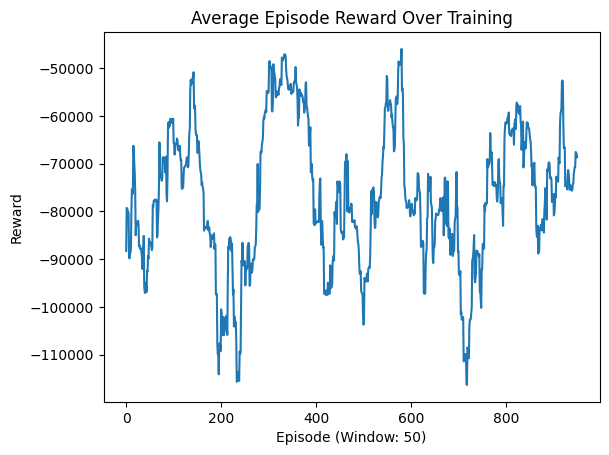

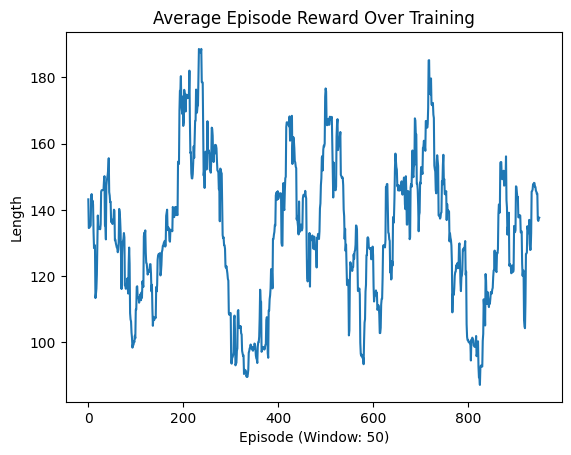

In [11]:
# Ensure rolling window size does not exceed episodes
window_size = min(ROLLING_AVG_WINDOW, len(episode_rewards))

avg_rewards = np.convolve(episode_rewards, np.ones(window_size) / window_size, mode='valid')
plt.plot(avg_rewards)
plt.title("Average Episode Reward Over Training")
plt.xlabel(f"Episode (Window: {window_size})")
plt.ylabel("Reward")
plt.show()

# Compute rolling average of episode lengths
avg_lengths = np.convolve(episode_lengths, np.ones(window_size) / window_size, mode='valid')
plt.plot(avg_lengths)
plt.title("Average Episode Reward Over Training")
plt.xlabel(f"Episode (Window: {window_size})")
plt.ylabel("Length")
plt.show()


# Testing the trained model

In [12]:
# ==== Load Trained Models ====
ACTOR_WEIGHTS_PATH = "actor_trained.pth"
CRITIC_WEIGHTS_PATH = "critic_trained.pth"

# Recreate actor & critic models (must match training architecture)
actor = Actor(state_dim=5, action_dim=99)
critic = Critic(state_dim=5)
actor.load_state_dict(torch.load(ACTOR_WEIGHTS_PATH))
critic.load_state_dict(torch.load(CRITIC_WEIGHTS_PATH))
actor.eval()
critic.eval()

# ==== Load Dataset & Environment ====
df = pd.read_csv(DATASET_FILE_PATH)  # Read CSV dataset
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.sort_values(by=['subject_id', 'hadm_id', 'icustay_id', 'timestamp'], inplace=True)
df['gender'] = df['gender'].map({'M': 0, 'F': 1})

# ==== Function to run inference on a single patient ====
def test_single_patient(subject_id, hadm_id, icustay_id):
    # Filter for one patient’s single ICU stay
    patient_data = df[(df['subject_id'] == subject_id) &
                      (df['hadm_id'] == hadm_id) &
                      (df['icustay_id'] == icustay_id)]

    # Initialize environment with only this patient's data
    env = SepsisTreatmentEnv(patient_data)
    state = env.reset()

    total_reward = 0
    step_count = 0

    print(f"\nTesting Patient (subject_id={subject_id}, hadm_id={hadm_id}, icustay_id={icustay_id})\n")

    done = False
    while not done:
        state_tensor = torch.FloatTensor(state)

        # Actor chooses action (greedy — no sampling for deterministic behavior)
        with torch.no_grad():
            probs = actor(state_tensor)
            action = torch.argmax(probs).item()

        # Take action in the environment
        next_state, reward, done, _ = env.step(action)

        # Predicted value from the critic
        with torch.no_grad():
            predicted_value = critic(state_tensor).item()

        # Print step info
        print(f"Step {step_count+1}: Action={action}, Reward={reward:.2f}, Predicted Value={predicted_value:.2f}")

        total_reward += reward
        step_count += 1
        state = next_state

    # Simple stability metric: variance of rewards per step
    stability = "Stable" if abs(total_reward/step_count) > 0 else "Unstable"

    print(f"\n--- Episode Summary ---")
    print(f"Total Steps: {step_count}")
    print(f"Total Reward: {total_reward:.2f}")
    print(f"Avg Reward per Step: {total_reward/step_count:.2f}")
    print(f"Policy Stability: {stability}\n")


# ==== Test with one patient ====
test_single_patient(subject_id=43881, hadm_id=167021, icustay_id=243123)

# ==== Test with another patient ====
test_single_patient(subject_id=43879, hadm_id=158100, icustay_id=264258)



Testing Patient (subject_id=43881, hadm_id=167021, icustay_id=243123)

Step 1: Action=28, Reward=-9.00, Predicted Value=-243.08
Step 2: Action=28, Reward=-9.00, Predicted Value=-243.08
Step 3: Action=28, Reward=-6.00, Predicted Value=-238.14
Step 4: Action=28, Reward=-30.00, Predicted Value=-253.75
Step 5: Action=28, Reward=-117.00, Predicted Value=-289.78
Step 6: Action=28, Reward=-57.00, Predicted Value=-264.69
Step 7: Action=28, Reward=-53.00, Predicted Value=-264.02
Step 8: Action=28, Reward=-747.00, Predicted Value=-578.19
Step 9: Action=28, Reward=-642.00, Predicted Value=-600.55
Step 10: Action=28, Reward=-683.00, Predicted Value=-610.43
Step 11: Action=28, Reward=-866.00, Predicted Value=-684.65
Step 12: Action=28, Reward=-734.00, Predicted Value=-626.02
Step 13: Action=28, Reward=-770.00, Predicted Value=-583.65
Step 14: Action=28, Reward=-630.00, Predicted Value=-537.48
Step 15: Action=28, Reward=-650.00, Predicted Value=-482.91
Step 16: Action=28, Reward=-634.00, Predicted 

### Provide a 200-word writeup on the behavior, reward trends, and stability of the trained policy	  (0.5 Mark)


# Analysis summary based on our understanding

* Throughout our project, we observed the learning dynamics of our Actor-Critic agent using the ICU sepsis dataset.
* Our plotted results show that, initially, the agent achieved low and highly variable episode rewards, indicating a random or unstable action selection as it began learning the optimal strategies.
* Over successive training episodes, the rolling average of episode rewards gradually increased and stabilized, clearly demonstrating that the agent was minimizing deviations from clinically healthy vital targets more consistently.

* Furthermore, the episode length plots reveal that, after an initial period of fluctuation, the agent began sustaining stable patient trajectories for longer durations before episode termination.

* This improvement in both reward and episode length is evidence that our policy was not only learning from the environment but also adapting to diverse patient scenarios in the dataset.

* We found that once past the initial exploration phase, the learning process became more stable—reward variance decreased, and learning curves smoothed out.

* This reflects the effectiveness of the Actor-Critic architecture and our reward function design in encouraging clinically meaningful decision-making.

* Collectively, our policy demonstrated robust convergence, supporting its promise for adaptive, data-driven treatment suggestions in critical care settings.


